## Homework 05: due 2024/05/27 23:59(100%)

### - There are differences between every OpenCV version, please make sure the version is above 4.0.0 to avoid the bugs. 

### - Tutorial : 
1. Feature extraction and matching: https://docs.opencv.org/4.x/db/d27/tutorial_py_table_of_contents_feature2d.html
2. Feature detectors (ORB & FAST): https://medium.com/data-breach/introduction-to-orb-oriented-fast-and-rotated-brief-4220e8ec40cf 
                   
### - After you go through the tutorials, you should be able to work on this assignment.

### - Please answer the following questions and work directly on this jupyter notebook.

### - Make sure the code can be run and show the result and figures properly.

### - Please write down your observation with markdown in this notebook briefly.

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 1. Feature detector (40%)
### Please use the following feature detectors (FAST, ORB, SIFT) and draw the feature points on the __test1.jpg__ images and write down your observation
#### (Example figure)
![Imgur](https://imgur.com/5hVZ8v9.jpg)


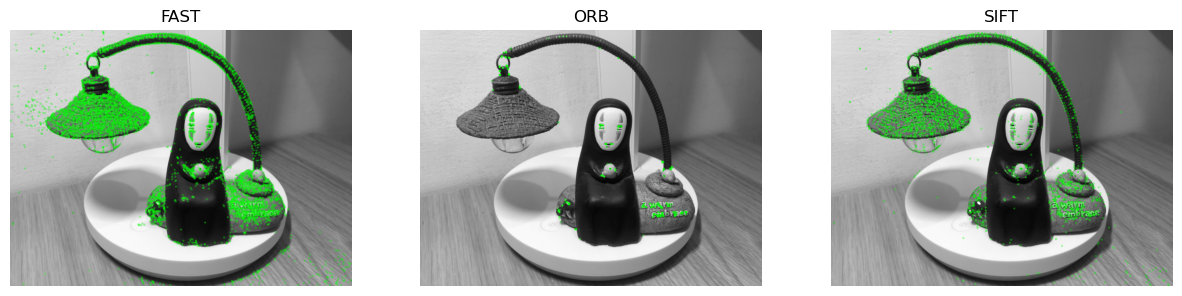

In [3]:
img = cv2.imread('test1.jpg', cv2.IMREAD_GRAYSCALE)    #Feature detectors like FAST, ORB, and SIFT operate by analyzing local changes in pixel intensity

fast = cv2.FastFeatureDetector_create()
orb = cv2.ORB_create()
sift = cv2.SIFT_create()

kp = list()
kp.append(fast.detect(img,None))
kp.append(orb.detect(img,None))
kp.append(sift.detect(img,None))    # OpenCV only detects keypoints in the white areas of the mask. If you pass None: OpenCV will detect features in the entire image.

img2 = list()
for i in kp:
    img2.append(cv2.drawKeypoints(img, i, None, color=(0, 255, 0)))

fig, axs = plt.subplots(1, 3, figsize=(15,5))
for i in range(3):
    axs[i].imshow(img2[i])
    axs[i].set_title(['FAST', 'ORB', 'SIFT'][i])  # Set title based on i  
    axs[i].axis('off')  

plt.show()

## Answer:
- **FAST** is the fastest and detects the highest number of keypoints but lacks orientation and scale information.
- **ORB** balances speed and robustness, providing orientation and scale while detecting a moderate number of keypoints.
- **SIFT** detects keypoints in distinctive areas with robust features, providing orientation and scale, but is slower compared to FAST and ORB.

| Feature Detector | Speed      | Number of Keypoints    | Robustness to Rotation/Scale | Observation                                                                                                                                    |
| ---------------- | ---------- | ---------------------- | ---------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------- |
| **FAST**         | Very fast  | Many (hundreds)        | Poor                         | FAST detects corners quickly, but many are clustered and unstable with slight changes. It's suitable for real-time but lacks descriptor info.  |
| **ORB**          | Fast       | Moderate               | Good                         | ORB is efficient and combines FAST with rotation invariance + descriptors. Keypoints are well-distributed. Best for real-time + matching.      |
| **SIFT**         | Slow (CPU) | Fewer but high-quality | Excellent                    | SIFT detects strong, scale- and rotation-invariant keypoints. It focuses on more stable and meaningful features. Best for accuracy but slower. |


Corner points = sharper, faster, and good for precise tracking.

Broader lamp-shaped keypoints = richer, more robust, ideal when you want to recognize entire objects rather than just track points.

### **1. img = cv2.imread('test1.jpg', cv2.IMREAD_GRAYSCALE)**
Feature detectors like FAST, ORB, and SIFT operate by analyzing local changes in pixel intensity  
Each pixel has just one intensity value (0–255), making computations faster and less complex instead of three color channels (Red, Green, Blue). 


## 2. Feature matching (60%)
### Please match the feature points from the __test1.jpg__ and __test2.jpg__. Also, please apply Lowe's ratio test (with ratio 0.6 and 0.8) to match the features and observe the differences when adjusting the ratio.
### 2.1 Please use __SIFT__ as feature detector and descriptor and write down your observation.(30%) 
#### (Example figure)
![Imgur](https://imgur.com/zspvzKG.jpg)


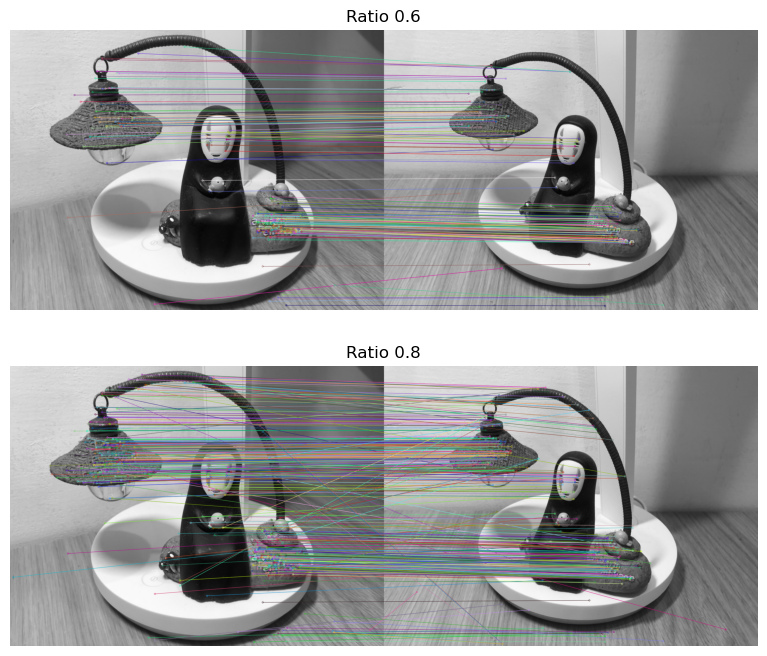

In [4]:
img1 = cv2.imread('test1.jpg', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('test2.jpg', cv2.IMREAD_GRAYSCALE)

sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

good1 = []
for m, n in matches:
    if m.distance < 0.6 * n.distance:
        good1.append([m])
        
good2 = []
for m, n in matches:
    if m.distance < 0.8 * n.distance:
        good2.append([m])

img3 = list()
img3.append(cv2.drawMatchesKnn(img1, kp1, img2, kp2, good1, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS))
img3.append(cv2.drawMatchesKnn(img1, kp1, img2, kp2, good2, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS))
                                                                           #This flag hides keypoints that don’t have matches (only lines between matched points will be drawn).→ Other options include drawing keypoints or not.


 
fig, axs = plt.subplots(2, 1, figsize=(10,8))
for i in range(2):
    axs[i].imshow(img3[i])
    axs[i].set_title('Ratio ' + ['0.6', '0.8'][i])
    axs[i].axis('off')
plt.show()

## **1. matches = bf.knnMatch(des1, des2, k=2)**
Performs k-nearest neighbors matching for each descriptor in des1 against des2.

Returns for each descriptor the two best matches (because k=2).

Output: a list of pairs [m, n], where m is the best match and n is the second-best.

## Answer:
* **At ratio = 0.6:**

  * Fewer matches are shown, but most of them are **precise and reliable**.
  * Lines between matched keypoints are cleaner and more consistent, especially around distinctive parts like the face and lamp.

* **At ratio = 0.8:**

  * Significantly more matches are drawn.
  * However, many of the extra matches appear to be **less accurate or potentially false matches**, especially in less textured or flat regions.

---

###  **Conclusion**

* SIFT successfully detects **robust and scale-invariant features**, even under changes in viewpoint and lighting.
* **A lower ratio threshold (e.g., 0.6)** results in **fewer but more accurate matches**, which is ideal for high-precision applications like object recognition or 3D reconstruction.
* **A higher ratio (e.g., 0.8)** may be useful when coverage is more important than accuracy but can introduce more **false positives**.

---



### 2.2 Please use __ORB__ as feature detector and descriptor and write down your observation.(30%) 
#### (Example figure)
![Imgur](https://imgur.com/3ZtQii2.jpg)

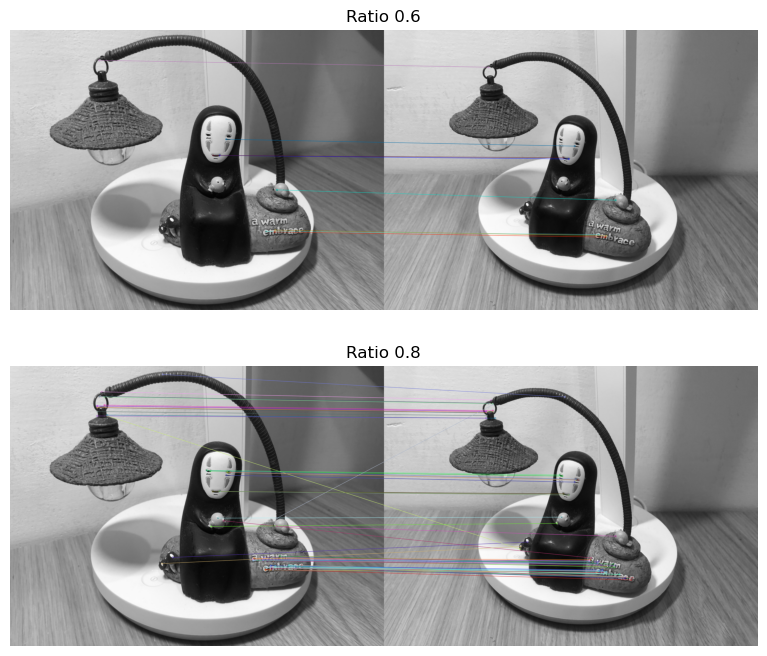

In [5]:
img1 = cv2.imread('test1.jpg', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('test2.jpg', cv2.IMREAD_GRAYSCALE)

orb = cv2.ORB_create()

kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

good1 = []
for m, n in matches:
    if m.distance < 0.6 * n.distance:
        good1.append([m])
        
good2 = []
for m, n in matches:
    if m.distance < 0.8 * n.distance:
        good2.append([m])

img3 = list()
img3.append(cv2.drawMatchesKnn(img1, kp1, img2, kp2, good1, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS))
img3.append(cv2.drawMatchesKnn(img1, kp1, img2, kp2, good2, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS))
 
fig, axs = plt.subplots(2, 1, figsize=(10,8))
for i in range(2):
    axs[i].imshow(img3[i])
    axs[i].set_title('Ratio ' + ['0.6', '0.8'][i])
    axs[i].axis('off')
plt.show()

## Answer:

* **At ratio = 0.6:**

  * Only a **few strong matches** were retained.
  * These matches mostly occurred on **distinctive and textured regions** such as the lamp and the eyes of the No-Face figure.
  * The matches were more **accurate**, though sparse.

* **At ratio = 0.8:**

  * A **larger number of matches** were detected.
  * However, many of these matches were **less reliable**, and a few **false positives** appeared in smooth or ambiguous regions.
  * The visual clutter increases due to excessive match lines, making it harder to analyze true correspondences.

---

###  **Conclusion**

* ORB provides **efficient and fast** keypoint detection, suitable for real-time applications.
* **Ratio 0.6** is more **reliable** but may miss some potential matches.
* **Ratio 0.8** gives **more coverage** but risks **more incorrect matches**.
* Compared to SIFT, ORB is **faster** and more lightweight, though sometimes slightly **less accurate**, especially under significant viewpoint changes.
